In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def pad_zero(X, pad):
    X_pad = np.pad(X, ((0, 0),(pad, pad),(pad, pad),(0,0)),mode = "constant" ,  constant_values = (0,0))
    return X_pad

In [5]:
np.random.seed(1)
x = np.random.randn(4,3,3,1)
x_pad = pad_zero(x, 3)
print ("x.shape =\n", x.shape)
print ("x_pad.shape =\n", x_pad.shape)
print ("x[1,1] =\n", x[1, 1])
print ("x_pad[1,1] =\n", x_pad[1, 1])

x.shape =
 (4, 3, 3, 1)
x_pad.shape =
 (4, 9, 9, 1)
x[1,1] =
 [[-0.3224172 ]
 [-0.38405435]
 [ 1.13376944]]
x_pad[1,1] =
 [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


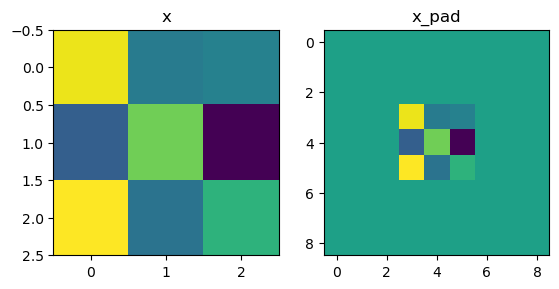

In [6]:
fig, axarr = plt.subplots(1, 2)
axarr[0].set_title('x')
axarr[0].imshow(x[0, :, :, 0])
axarr[1].set_title('x_pad')
axarr[1].imshow(x_pad[0, :, :, 0])

In [7]:
grayscale_image = np.random.randint(0, 256, size=(5 ,5, 5), dtype=np.uint8)

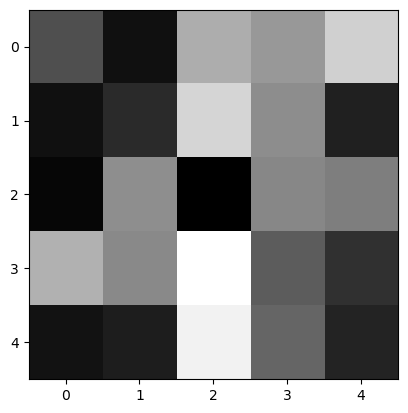

In [8]:
plt.imshow(grayscale_image[1], cmap='gray')

In [24]:
def conv_single_step(a_slice_prev, W, b):
    Z = np.sum(a_slice_prev * W) + float(b)
    return Z

In [106]:
# def conv_forward(A_prev, W, b, hparameters):
#     f = W.shape[1]
#     n = A_prev.shape[1]
#     output_dim = n - f + 1 
#     output = np.zeros((output_dim, output_dim))
#     for i in range(output_dim):
#         for j in range(output_dim):
#             output[i,j] = np.sum(A_prev[:,i:i+f,j:j+f] * W) + b
#     return output


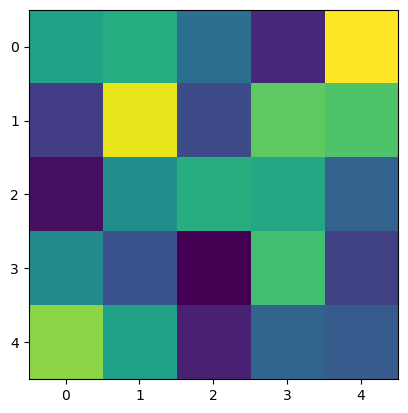

In [102]:
image = np.random.randn(10,5,5,3)
filt = np.random.randn(1,3,3,3)
b = np.random.randn(1,1,1,3)
hparameters = {"stride": 1,
               "pad": 2}

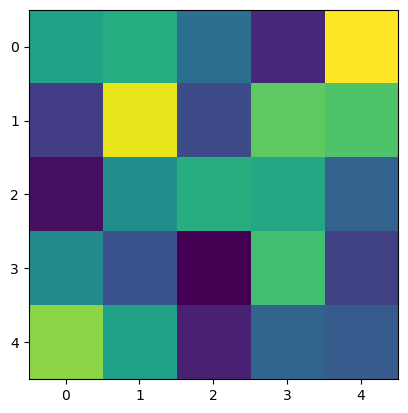

In [109]:
plt.imshow(image[0])

/tmp/ipykernel_3880/3049862150.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output[i,j] = np.sum(A_prev[:,i:i+f,j:j+f] * W) + b


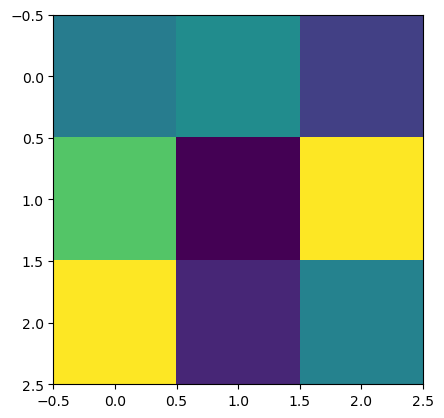

In [107]:
output = conv_forward(image, filt, b,None)
plt.imshow(output)

In [123]:
def conv_forward(A_prev, W, b, hparameters):
    (m, n_H_prev, n_W_prev, n_c_prev) =  A_prev.shape
    (f,f,n_c_prev, n_c) = W.shape
    stride = hparameters["stride"]
    pad = hparameters["pad"]
    n_H = int((n_H_prev - f + 2 * pad)/stride) + 1
    n_W = int((n_W_prev - f + 2 * pad)/stride) + 1

    Z = np.zeros((m, n_H, n_W, n_c))
    A_prev_Pad = pad_zero(A_prev, pad)
    

    for i in range(m):
        a_prev_pad = A_prev_Pad[i]
        for h in range(n_H):
            vert_start = h * stride
            vert_end = vert_start + f
            for w in range(n_W):
                horiz_start = w * stride
                horiz_end = horiz_start + f
                for c in range(n_c):
                    a_slice_prev = a_prev_pad[vert_start:vert_end,horiz_start:horiz_end,:]
                    weights = W[:,:,:,c]
                    biases = b[:,:,:,c]
                    Z[i, h, w, c] =  conv_single_step(a_slice_prev, weights, biases)
    cache = (A_prev, W, b, hparameters)
    return Z, cache

In [128]:
A_prev = np.random.randn(2, 5, 7, 4)
W = np.random.randn(3, 3, 4, 8)
b = np.random.randn(1, 1, 1, 8)
hparameters = {"pad" : 1,
               "stride": 2}
img = conv_forward(A_prev, W, b, hparameters)
img

/tmp/ipykernel_3880/2630260504.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, h, w, c] =  conv_single_step(a_slice_prev, weights, biases)


(array([[[[ -4.62839253,   0.775294  ,  -2.38814793,  -3.16653922,
             2.22610334,   6.51644342,  13.97249669,  -1.64053002],
          [  8.35370008,  -0.11489201,   0.39519559,   2.79476402,
             2.71512053,  -3.86356717,   0.04434755,   2.3093265 ],
          [ -2.5176259 ,   6.19713976,   6.77822578,  -3.27593584,
            -4.87364178,  12.81002963,   0.20418441,   0.86262586],
          [  4.42350714,  -5.99104431,   1.1559056 ,  -2.64279582,
            -1.91487128,  -4.84604905,   1.03880284,   1.13088996]],
 
         [[ -3.88370837,  -1.52392343,   2.031314  ,   1.35811187,
           -10.00124233,   0.45880401,  -1.77034218,  -0.31168813],
          [ -8.18511048,  -1.50315852,  -1.7581797 ,   7.5443521 ,
             5.60916384,  -8.53267359,  -1.18565951,  -2.36957004],
          [ -2.80641918,   3.88144437, -12.37646851,   3.85957509,
            -3.61657801,   3.37708166,   7.69032324,  -5.35850737],
          [  0.55896126,  -5.75877217,   6.18775054,